In [ ]:
"""
This section imports all required libraries for scRNA-seq analysis.
Designed to ensure reproducibility across environments.
"""
import os, glob, re
import numpy as np
import pandas as pd
import scipy.io, scipy.sparse as sp
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import tarfile

In [ ]:
base_dir   = "/Users/nguyenduongthieutran/projects/GSE282701"
tar_path   = os.path.join(base_dir, "GSE282701_RAW.tar")
extract_dir = os.path.join(base_dir, "raw_extracted")
os.makedirs(extract_dir, exist_ok=True)
with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_dir)
output_dir = os.path.join(base_dir, "results")
fig_dir    = os.path.join(output_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)
sc.settings.figdir = fig_dir


In [ ]:
matrix_paths = sorted(glob.glob(os.path.join(extract_dir, "GSM*_matrix.mtx.gz")))
rows = []
for mp in matrix_paths:
    fn = os.path.basename(mp)
    # GSM8649028_011T_matrix.mtx.gz
    m = re.match(r"(GSM\d+)_(\d{3})([TP])_matrix\.mtx\.gz$", fn)
    if not m:
        raise ValueError(f"Unexpected filename pattern: {fn}")
    gsm, pid_num, tissue_code = m.group(1), m.group(2), m.group(3)
    patient_id = f"P{int(pid_num)}"         # 011 -> P11
    tissue = "Tumor" if tissue_code == "T" else "Adjacent"

    rows.append({
        "dataset_id": "GSE282701",
        "sample_id": gsm,
        "patient_id": patient_id,
        "tissue": tissue,
        "platform": "Illumina NovaSeq 6000",
        "batch": f"{patient_id}_{tissue}",
        "matrix_path": mp,
    })
meta = pd.DataFrame(rows)

# add HBV status 
hbv_map = {
    "GSM8649020":"HBV_neg","GSM8649021":"HBV_neg",
    "GSM8649022":"HBV_neg","GSM8649023":"HBV_neg",
    "GSM8649024":"HBV_pos","GSM8649025":"HBV_pos",
    "GSM8649026":"HBV_pos","GSM8649027":"HBV_pos",
    "GSM8649028":"HBV_neg","GSM8649029":"HBV_neg",
    "GSM8649030":"HBV_pos","GSM8649031":"HBV_pos",
}
meta["etiology"] = meta["sample_id"].map(hbv_map)
meta["disease"] = "HCC"
meta["sample_name"] = meta["patient_id"] + "," + meta["tissue"] + "," + meta["etiology"]
# tumor-only 
meta_tumor = meta.query("tissue == 'Tumor'").copy()
meta_tumor.head(12)

,dataset_id,sample_id,patient_id,tissue,platform,batch,matrix_path,etiology,disease,sample_name
0,GSE282701,GSM8649020,P15,Tumor,Illumina NovaSeq 6000,P15_Tumor,/Users/nguyenduongthieutran/projects/GSE282701...,HBV_neg,HCC,"P15,Tumor,HBV_neg"
2,GSE282701,GSM8649022,P14,Tumor,Illumina NovaSeq 6000,P14_Tumor,/Users/nguyenduongthieutran/projects/GSE282701...,HBV_neg,HCC,"P14,Tumor,HBV_neg"
4,GSE282701,GSM8649024,P13,Tumor,Illumina NovaSeq 6000,P13_Tumor,/Users/nguyenduongthieutran/projects/GSE282701...,HBV_pos,HCC,"P13,Tumor,HBV_pos"
6,GSE282701,GSM8649026,P12,Tumor,Illumina NovaSeq 6000,P12_Tumor,/Users/nguyenduongthieutran/projects/GSE282701...,HBV_pos,HCC,"P12,Tumor,HBV_pos"
8,GSE282701,GSM8649028,P11,Tumor,Illumina NovaSeq 6000,P11_Tumor,/Users/nguyenduongthieutran/projects/GSE282701...,HBV_neg,HCC,"P11,Tumor,HBV_neg"
10,GSE282701,GSM8649030,P10,Tumor,Illumina NovaSeq 6000,P10_Tumor,/Users/nguyenduongthieutran/projects/GSE282701...,HBV_pos,HCC,"P10,Tumor,HBV_pos"


In [4]:
def load_gsm_10x_triplet_282701(matrix_fp: str) -> ad.AnnData:
    base = matrix_fp.replace("_matrix.mtx.gz", "")
    features_fp = base + "_features.tsv.gz"
    barcodes_fp = base + "_barcodes.tsv.gz"

    X = scipy.io.mmread(matrix_fp).T.tocsr()

    feat = pd.read_csv(features_fp, header=None, sep="\t")
    bar = pd.read_csv(barcodes_fp, header=None, sep="\t")

    var = pd.DataFrame()
    if feat.shape[1] >= 1:
        var["gene_id"] = feat.iloc[:, 0].astype(str).values
    if feat.shape[1] >= 2:
        var["gene_symbol"] = feat.iloc[:, 1].astype(str).values
    else:
        var["gene_symbol"] = var["gene_id"]
    if feat.shape[1] >= 3:
        var["feature_type"] = feat.iloc[:, 2].astype(str).values
    else:
        var["feature_type"] = "Gene Expression"

    obs = pd.DataFrame(index=bar.iloc[:, 0].astype(str).values)

    adata = ad.AnnData(X=X, obs=obs, var=var)

    adata.var["gene_symbol"] = adata.var["gene_symbol"].astype(str)
    adata.var["gene_symbol_unique"] = adata.var["gene_symbol"].values
    adata.var_names = adata.var["gene_symbol_unique"].values
    adata.var_names_make_unique()

    return adata

In [5]:
adatas = []
for _, r in meta_tumor.iterrows():
    a = load_gsm_10x_triplet_282701(r["matrix_path"])
    a.var_names_make_unique()

    for col in ["dataset_id","sample_id","sample_name","patient_id","disease","etiology","tissue","platform","batch"]:
        a.obs[col] = r[col]

    a.obs_names = [f"{r['sample_id']}_{bc}" for bc in a.obs_names]
    adatas.append(a)

adata_all = ad.concat(adatas, join="inner", merge="same")
adata_all.var_names_make_unique()
print(adata_all)
adata_all.write(os.path.join(output_dir, "adata_raw_merged.h5ad"))

/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitMod

AnnData object with n_obs × n_vars = 76043 × 36591
    obs: 'dataset_id', 'sample_id', 'sample_name', 'patient_id', 'disease', 'etiology', 'tissue', 'platform', 'batch'
    var: 'gene_id', 'gene_symbol', 'feature_type', 'gene_symbol_unique'


In [ ]:
adata = adata_all.copy()
# QC annotations
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

# sc.pl.violin(
#     adata,
#     ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
#     groupby="etiology",
#     jitter=0.2,
#     multi_panel=True,
#     show=False
# )
savefig("qc_violin_by_batch.png")

# Filtering thresholds
min_genes = 200
max_mt = 20
max_genes = np.quantile(adata.obs["n_genes_by_counts"], 0.995)
max_counts = np.quantile(adata.obs["total_counts"], 0.995)

adata = adata[
    (adata.obs["n_genes_by_counts"] >= min_genes) &
    (adata.obs["n_genes_by_counts"] <= max_genes) &
    (adata.obs["total_counts"] <= max_counts) &
    (adata.obs["pct_counts_mt"] <= max_mt)
].copy()
sc.pp.filter_genes(adata, min_cells=3)
adata.write(os.path.join(output_dir, "GSE282701_HCC_QC.h5ad"))
adata

AnnData object with n_obs × n_vars = 72217 × 31028
    obs: 'dataset_id', 'sample_id', 'sample_name', 'patient_id', 'disease', 'etiology', 'tissue', 'platform', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_id', 'gene_symbol', 'feature_type', 'gene_symbol_unique', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [19]:
'''
Counts are normalized to a constant library size and log-transformed for downstream feature selection and clustering
'''
# Store raw counts before normalization for later reference if needed.
adata.raw = adata
# normalize + log
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata )
# HVG 
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=3000,
    batch_key="batch",
    subset=False
)
# sc.pl.highly_variable_genes(adata, show=False)
savefig("hvg_plot.png")
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
adata_hvg

/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


AnnData object with n_obs × n_vars = 72217 × 3000
    obs: 'dataset_id', 'sample_id', 'sample_name', 'patient_id', 'disease', 'etiology', 'tissue', 'platform', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_id', 'gene_symbol', 'feature_type', 'gene_symbol_unique', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg'

In [ ]:
#Scaling and PCA
'''Scale expression values and run PCA on the HVG matrix.'''
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata_hvg, log=True, show=False)
savefig("pca_variance.png")

In [21]:
# Neighbors, UMAP, and Leiden clustering
'''Build the graph structure used for visualization and clustering'''
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata_hvg)
sc.tl.leiden(adata_hvg, resolution=0.4)
adata_hvg.write(os.path.join(output_dir, "adata_hvg_umap_leiden.h5ad"))

In [ ]:
'''This stage scores cells using a positive HSC signature and three exclusion programs (immune, endothelial, epithelial) to enrich for stellate cell candidates'''
# Prepare aligned object for module scoring
'''
Use the full-gene object for scoring whenever possible so that
Gene-set coverage is not reduced by HVG subsetting
'''
def keep_genes(adata_obj, genes):
    gs = []
    vset = set(adata_obj.var_names.astype(str))
    for g in genes:
        g2 = str(g)
        if g2 in vset:
            gs.append(g2)
    return gs

def ensure_obs_alignment(a_src, a_tgt):
    if not a_src.obs_names.equals(a_tgt.obs_names):
        a_src = a_src[a_tgt.obs_names, :].copy()
    return a_src

if "adata" in globals():
    adata_score = ensure_obs_alignment(adata, adata_hvg)
else:
    adata_score = adata_hvg.copy()

In [22]:
# HSC / exclusion gene-program scoring
'''
Convert marker symbols to the correct gene IDs, then score:
- HSC core program
- immune exclusion program
- endothelial exclusion program
- epithelial exclusion program
'''
def keep_genes(adata, genes):
    present_genes = []
    adata_var_names_set = set(adata.var_names.astype(str))
    for gene_symbol in genes:
        if gene_symbol in adata_var_names_set:
            present_genes.append(gene_symbol)
    return present_genes

HSC_CORE = ["LRAT","RBP1","PDGFRB","DES","GFAP","DCN","LUM","COL1A1","COL1A2","COL3A1","RGS5",
            "RELN","PPARG","NGFR","CYGB","COLEC11","PPARA","FOXF1","IGFBP7","IGFBP6",
            "WT1","FGF10","MEG3","OLFML3","IGFBP3","SEMA7A","NR1H4","PDGFRA","CYR61",
            "VCL","SYP","MYB","AGTR1","HGF","ACTA2","TIMP1","SPARC","MYL9","CD36",
            "TAGLN","CTGF","BGN","TPM2","GFAP","FAP","AEBP1","ITGAV","LOXL2","SERPINE1","LTBP2",
            "CREM","CCL2","VEGFA","SLC8A1","GAS7","EFEMP1","SPON1","KLF9","S100A6"
]
IMMUNE   = ["PTPRC","LYZ","LST1","TYROBP","FCN1","CD3D","CD3E","MS4A1","NKG7","GNLY"]
ENDO     = ["PECAM1","VWF","KDR","RAMP2","GNG11","CLEC14A"]
EPI      = ["ALB","APOA1","APOC1","TTR","KRT8","KRT18","KRT19","EPCAM"]

#score genes
core = keep_genes(adata_score, HSC_CORE)
imm  = keep_genes(adata_score, IMMUNE)
endo = keep_genes(adata_score, ENDO)
epi  = keep_genes(adata_score, EPI)
print("Present genes:", {"HSC_CORE":len(core), "IMMUNE":len(imm), "ENDO":len(endo), "EPI":len(epi)})

if len(core) < 4:
    raise ValueError(f"Too few HSC_CORE genes present ({len(core)}). Check var_names or gene symbols.")
if len(imm) < 4:
    print("Warning: IMMUNE gene list is small; anti-score may be weaker.")
if len(endo) < 3:
    print("Warning: ENDO gene list is small; anti-score may be weaker.")
if len(epi) < 3:
    print("Warning: EPI gene list is small; anti-score may be weaker.")

sc.tl.score_genes(adata_score, core, score_name="HSC_score", use_raw=False)
sc.tl.score_genes(adata_score, imm,  score_name="Immune_score", use_raw=False)
sc.tl.score_genes(adata_score, endo, score_name="Endo_score", use_raw=False)
sc.tl.score_genes(adata_score, epi,  score_name="Epi_score", use_raw=False)
for c in ["HSC_score","Immune_score","Endo_score","Epi_score"]:
    adata_hvg.obs[c] = adata_score.obs[c].values

# visualize
# sc.pl.umap(
#     adata_hvg,
#     color=["HSC_score","Immune_score","Endo_score","Epi_score"],
#     wspace=0.4,
#     show=False
# )

Present genes: {'HSC_CORE': 57, 'IMMUNE': 10, 'ENDO': 6, 'EPI': 8}


In [13]:
hsc_cells = adata_hvg.obs_names[adata_hvg.obs["is_HSC_candidate"]].tolist()
if "adata" in globals():
    adata_hsc = adata[hsc_cells, :].copy()
else:
    adata_hsc = adata_hvg[hsc_cells, :].copy()
adata_hsc.write(os.path.join(output_dir, "GSE282701_HSC_candidates.h5ad"))
adata_hsc

AnnData object with n_obs × n_vars = 10536 × 31028
    obs: 'dataset_id', 'sample_id', 'sample_name', 'patient_id', 'disease', 'etiology', 'tissue', 'platform', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'HSC_score', 'Immune_score', 'Endo_score', 'Epi_score'
    var: 'gene_id', 'gene_symbol', 'feature_type', 'gene_symbol_unique', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'etiology_colors', 'log1p', 'hvg'

In [ ]:
'''After enrichment, the HSC compartment is reprocessed independently to improve subtype resolution before functional state assignment'''
# Recompute HVGs, PCA, graph, and Leiden clusters within the HSC subset
sc.pp.highly_variable_genes(adata_hsc, n_top_genes=2000, flavor="seurat", subset=False)
sc.pp.scale(adata_hsc, max_value=10)
sc.tl.pca(adata_hsc, svd_solver="arpack", use_highly_variable=True)
sc.pp.neighbors(adata_hsc, n_neighbors=15, n_pcs=20)
sc.tl.umap(adata_hsc)
sc.tl.leiden(adata_hsc, resolution=0.4)

/opt/miniconda3/envs/scrna_stable/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]


In [15]:
if "gene_symbol" in adata_hsc.var.columns:
    adata_hsc.var["gene_symbol"] = adata_hsc.var["gene_symbol"].astype(str)
    adata_hsc.var_names = adata_hsc.var["gene_symbol"].values
    adata_hsc.var_names_make_unique()

def keep_genes(adata_obj, genes):
    gset = set(adata_obj.var_names.astype(str))
    return [g for g in genes if g in gset]
if "log1p" not in adata_hsc.uns:
    sc.pp.normalize_total(adata_hsc, target_sum=1e4)
    sc.pp.log1p(adata_hsc)

adata_hsc.raw = adata_hsc

HSC_state
INF_HSC    2935
aHSC_A2    2892
qHSC       2499
aHSC_A1    2210
Name: count, dtype: int64


/var/folders/lj/02z_qz8d0jv6_4l1bdd4xs400000gn/T/ipykernel_8602/599972327.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = adata_hsc.obs.groupby("leiden")[["Q_score","A1_score","A2_score","INF_score"]].mean()
/var/folders/lj/02z_qz8d0jv6_4l1bdd4xs400000gn/T/ipykernel_8602/599972327.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["etiology", "HSC_state"])


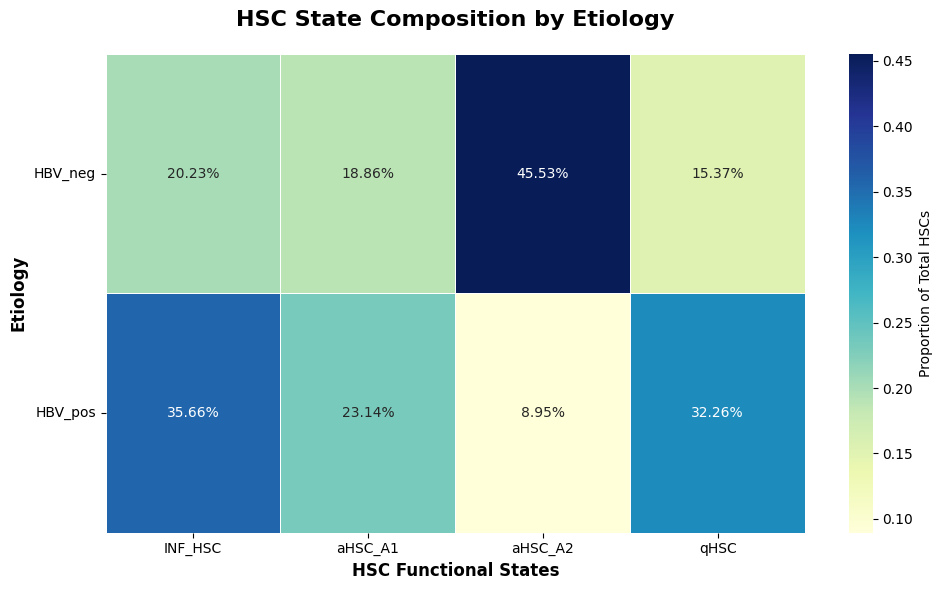

In [ ]:
# HSC functional state scoring and composition summary
'''Four state programs:
- qHSC: quiescent/homeostatic
- aHSC_A1: contractile / myofibroblast-like
- aHSC_A2: ECM-producing / fibrogenic
- INF_HSC: inflammatory'''
qHSC   = ["LRAT","RGS5","RELN","WT1","IGFBP3","RBP1","NR1H4","PPARG","COLEC11","CYGB","ADIRF","RARRES2"]  
A1_HSC  = ["ACTA2","TAGLN","MYL9","TPM2","CNN1","CALD1","NGFR","PDGFRA","CYR61","IGFBP7","IGFBP6", "VCL","SYP","MYB","AGTR1","ADAMTS13","HGF","FGF10"]  
A2_HSC  = ["DES", "GFAP","COL1A1","COL1A2","COL3A1","DCN","LUM","TIMP1","CTGF","SPARC", "MYL9","CTGF","TPM2","FAP","AEBP1","ITGAV","LOXL2","SERPINE1","LTBP2","S100A6"] 
INF = ["CCL2","CXCL2","CXCL8","IL6","NFKBIA","TNFAIP3","ICAM1","CXCL1","CD36","CLEC11A","CREM","VEGFA","CYR61","SLC8A1","GAS7","EFEMP1","SPON1","KLF9"]  
sc.tl.score_genes(adata_hsc, keep_genes(adata_hsc, qHSC),   score_name="Q_score",   use_raw=True)
sc.tl.score_genes(adata_hsc, keep_genes(adata_hsc, A1_HSC), score_name="A1_score",  use_raw=True)
sc.tl.score_genes(adata_hsc, keep_genes(adata_hsc, A2_HSC), score_name="A2_score",  use_raw=True)
sc.tl.score_genes(adata_hsc, keep_genes(adata_hsc, INF),score_name="INF_score", use_raw=True)

cluster_means = adata_hsc.obs.groupby("leiden")[["Q_score","A1_score","A2_score","INF_score"]].mean()
state_map = cluster_means.idxmax(axis=1).replace({
    "Q_score":"qHSC", "A1_score":"aHSC_A1", "A2_score":"aHSC_A2", "INF_score":"INF_HSC"
}).to_dict()
adata_hsc.obs["HSC_state"] = adata_hsc.obs["leiden"].map(state_map).astype("category")

score_cols = ["Q_score","A1_score","A2_score","INF_score"]
scores = adata_hsc.obs[score_cols].copy()
state = scores.idxmax(axis=1).replace({ "Q_score":"qHSC","A1_score":"aHSC_A1","A2_score":"aHSC_A2", "INF_score":"INF_HSC"})
adata_hsc.obs["HSC_state"] = state.astype("category")
print(adata_hsc.obs["HSC_state"].value_counts())

adata_hsc.obs["HSC_state"].value_counts()
adata_hsc.obs["etiology"].value_counts()

# Summarize proportions of HSC functional states across etiologies.
assert adata_hsc.raw is not None, "adata_hsc.raw must contain log-normalized data"
state_counts = (
    adata_hsc.obs
    .groupby(["etiology", "HSC_state"])
    .size()
    .unstack(fill_value=0)
)
state_props = state_counts.div(state_counts.sum(axis=1), axis=0)
import seaborn as sns
plt.figure(figsize=(10, 6))
ax = sns.heatmap(state_props, annot=True, fmt=".2%", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Proportion of Total HSCs'})
plt.title("HSC State Composition by Etiology", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("HSC Functional States", fontsize=12, fontweight='bold')
plt.ylabel("Etiology", fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()